In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from tqdm.notebook import tqdm

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

In [4]:
if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.empty_cache()
else:
    device = "cpu"

In [5]:
transform = transforms.Compose([transforms.ToTensor(),])

# Load the Fashion MNIST dataset
train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, transform=transform)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.1MB/s]


In [6]:
xl = []
yl = []
for x, y in train_dataset:
    xl.append(x)
    yl.append(y)
X_train = torch.stack(xl)
y_train = torch.tensor(yl)
cached_train = TensorDataset(X_train, y_train)
xl = []
yl = []
for x, y in test_dataset:
    xl.append(x)
    yl.append(y)
X_test = torch.stack(xl)
y_test = torch.tensor(yl)
cached_test = TensorDataset(X_test, y_test)
del xl
del yl

In [7]:
labels=\
{0: "T-shirt/top",
 1: "Trouser",
 2: "Pullover",
 3: "Dress",
 4: "Coat",
 5: "Sandal",
 6: "Shirt",
 7: "Sneaker",
 8: "Bag",
 9: "Ankle boot"}

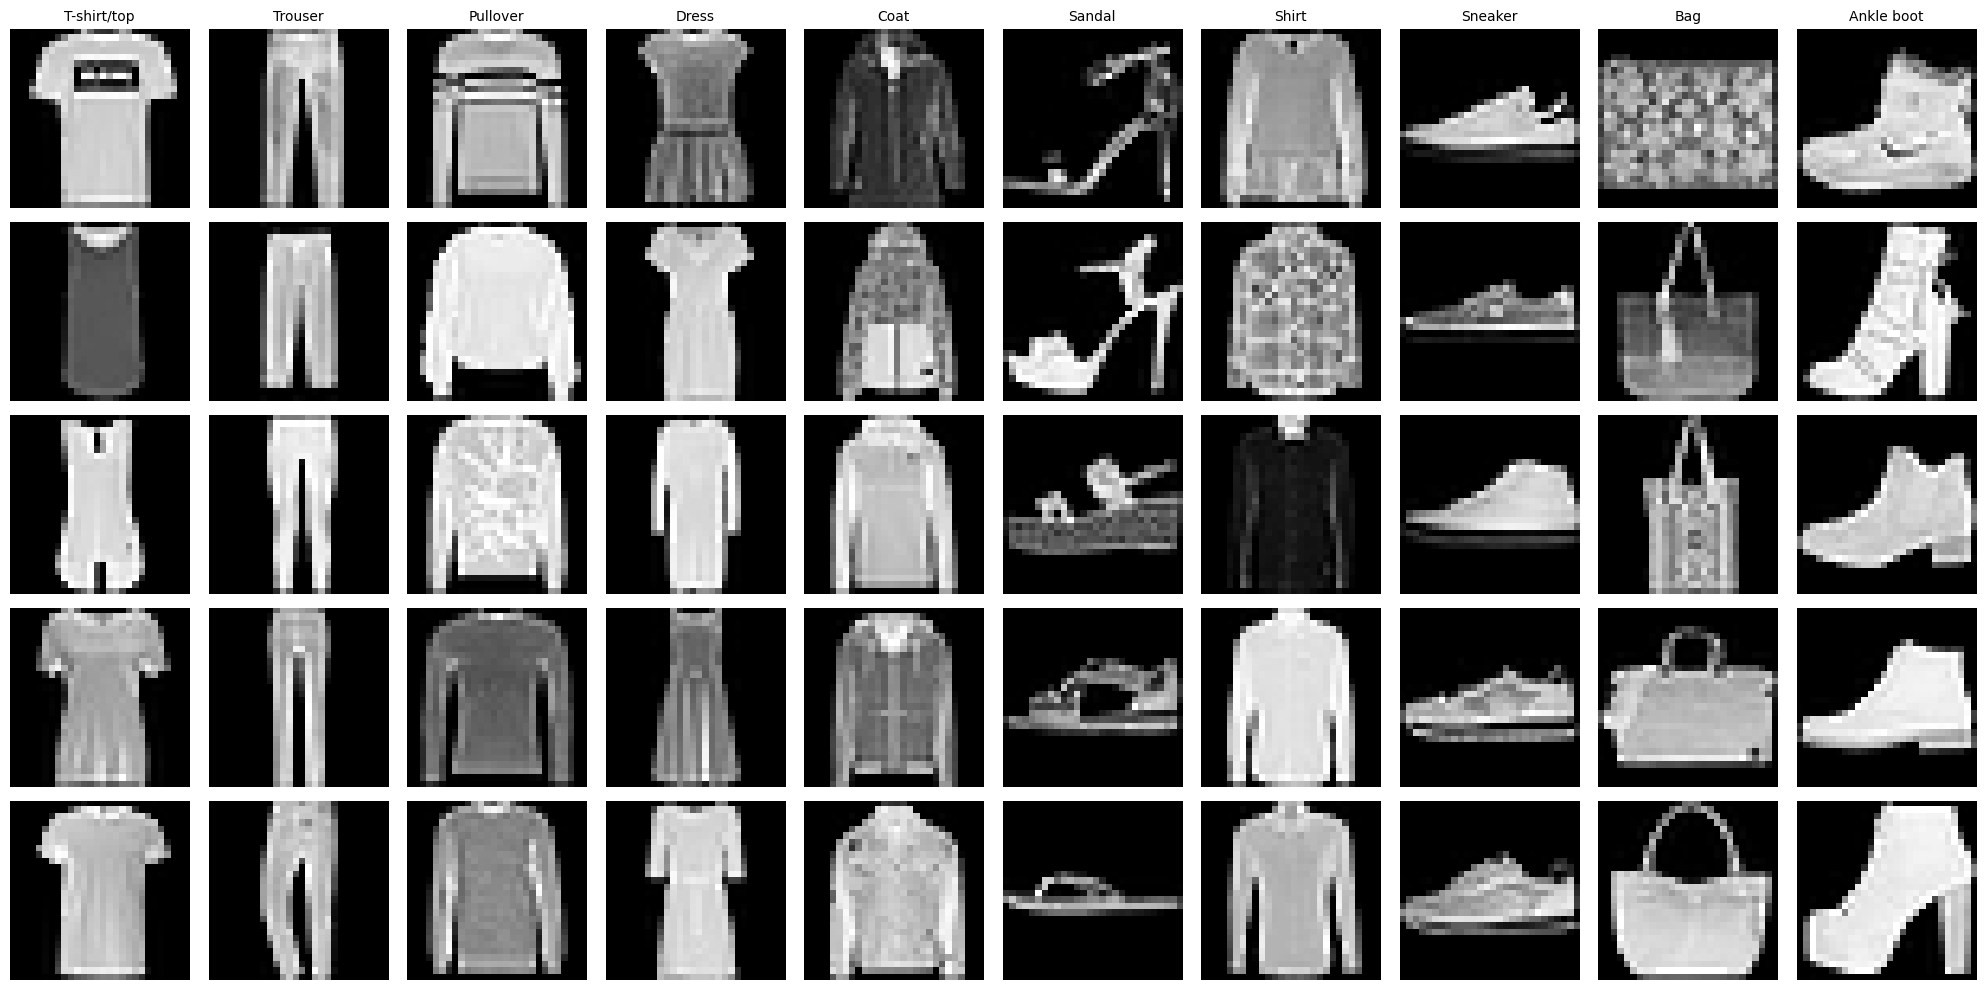

In [8]:
samples_per_class = {k: [] for k in range(10)}
for x, y in cached_train:
    label = y.item()
    if len(samples_per_class[label]) < 5:
        samples_per_class[label].append(x)
    if all(len(v) == 5 for v in samples_per_class.values()):
        break

# Plotting
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
for col in range(10):  # each class
    for row in range(5):  # 5 samples per class
        ax = axes[row, col]
        img = samples_per_class[col][row]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(labels[col], fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
train_dataloader = DataLoader(cached_train, batch_size=128, shuffle=True)
test_dataloader = DataLoader(cached_test, batch_size=128, shuffle=False)

In [10]:
def eval_net(net, d):
    net.eval()
    loss = torch.nn.CrossEntropyLoss(reduction="sum")
    with torch.no_grad():
        acc_sum = 0
        loss_sum = 0
        n = 0
        for x, y in d:
            y=y.to(device)
            x=x.to(device)
            pred = net(x)
            predicted = pred.argmax(axis=-1)
            acc_sum += (predicted==y).sum().item()
            loss_sum += loss(pred, y).item()
            n += x.shape[0]
    return acc_sum/n, loss_sum/n

In [11]:
def plot_history(hist):
    fig, ax = plt.subplots(ncols=2)
    ax[0].plot(hist['accuracy'], label="accuracy")
    if "val_accuracy" in hist:
        ax[0].plot(hist['val_accuracy'], label="val_accuracy")
    ax[1].plot(hist['loss'], label="loss")
    if "val_loss" in hist:
        ax[1].plot(hist['val_loss'], label="val_loss")
    fig.legend()

In [15]:
import torch.optim as optim
from torch.optim import lr_scheduler
import copy

def fit(net, train=train_dataloader, valid=test_dataloader, epochs=5,
        learning_rate=None):
    net = net.to(device)

    if learning_rate is None:
        optimizer = optim.Adam(net.parameters())
    else:
        optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    loss = torch.nn.CrossEntropyLoss()
    hist_loss_train = []
    hist_loss_valid = []
    hist_acc_train = []
    hist_acc_valid = []
    for e in tqdm(range(epochs)):
        net.train()
        for X, y in train:
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        acc_train, loss_train = eval_net(net, train)
        acc_valid, loss_valid = eval_net(net, valid)
        hist_loss_train.append(loss_train)
        hist_loss_valid.append(loss_valid)
        hist_acc_train.append(acc_train)
        hist_acc_valid.append(acc_valid)
        if valid is not None:
            print("Accuracy/loss at epoch", e, ":", acc_valid, loss_valid)
    ret = {"loss": hist_loss_train, "val_loss": hist_loss_valid,
           "accuracy": hist_acc_train, "val_accuracy": hist_acc_valid}
    return ret

In [13]:
m_cnn = nn.Sequential(nn.Conv2d(1, 64, 3), nn.ReLU(),
                   nn.Conv2d(64, 64, 3), nn.ReLU(),
                   nn.MaxPool2d(2),
                   nn.Conv2d(64, 256, 3), nn.ReLU(),
                   nn.MaxPool2d(2),
                   nn.Flatten(),
                   nn.Linear(256*5*5, 128), nn.ReLU(),
                   nn.Linear(128, 10),
)

  0%|          | 0/30 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8968 0.28708075428009033
Accuracy/loss at epoch 1 : 0.9083 0.2485489445090294
Accuracy/loss at epoch 2 : 0.9078 0.25221759231090546
Accuracy/loss at epoch 3 : 0.9157 0.23510970812439919
Accuracy/loss at epoch 4 : 0.9199 0.24335602798461914
Accuracy/loss at epoch 5 : 0.9255 0.22863777940869331
Accuracy/loss at epoch 6 : 0.9261 0.263916648709774
Accuracy/loss at epoch 7 : 0.925 0.2641821141004562
Accuracy/loss at epoch 8 : 0.926 0.2887040503501892
Accuracy/loss at epoch 9 : 0.9221 0.33350397534370424
Accuracy/loss at epoch 10 : 0.9237 0.3454427367210388
Accuracy/loss at epoch 11 : 0.9235 0.33796961666382846
Accuracy/loss at epoch 12 : 0.9207 0.37093326407754795
Accuracy/loss at epoch 13 : 0.9247 0.4371155958920717
Accuracy/loss at epoch 14 : 0.9239 0.3899933573484421
Accuracy/loss at epoch 15 : 0.9242 0.44829495882745835
Accuracy/loss at epoch 16 : 0.9224 0.44382345264517936
Accuracy/loss at epoch 17 : 0.92 0.4329669786244631
Accuracy/loss at epoch 18 : 0.922

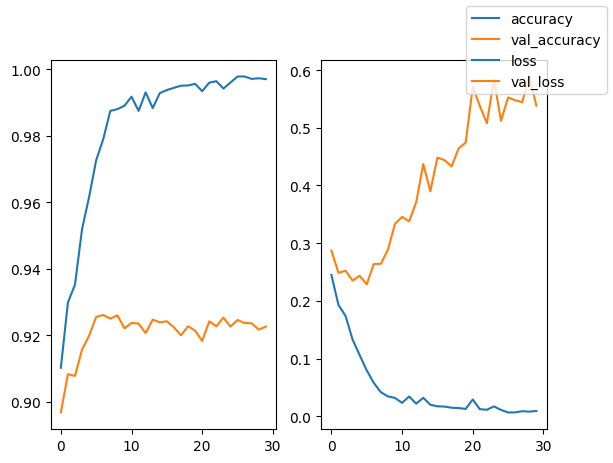

In [16]:
hist = fit(m_cnn, epochs=30, learning_rate=0.0001)
plot_history(hist)

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [18]:
with torch.no_grad():
    y_pred = m_cnn(X_test.to(device)).cpu()
    y_true = y_test

In [19]:
label_list = [labels[k] for k in sorted(labels.keys())]

In [20]:
y_pred = np.argmax(y_pred, axis=1)

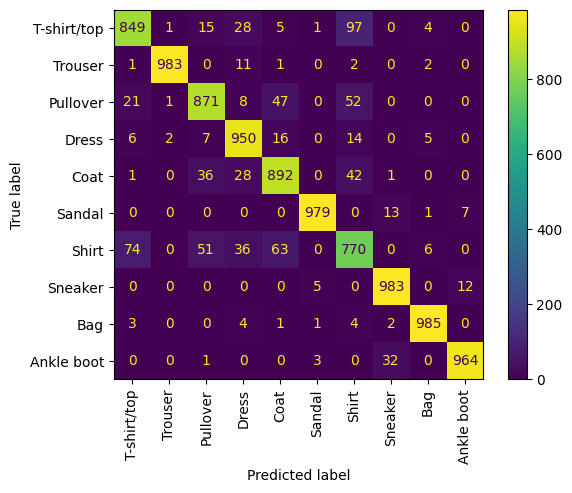

In [21]:
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                               display_labels=label_list,
                                               xticks_rotation="vertical")

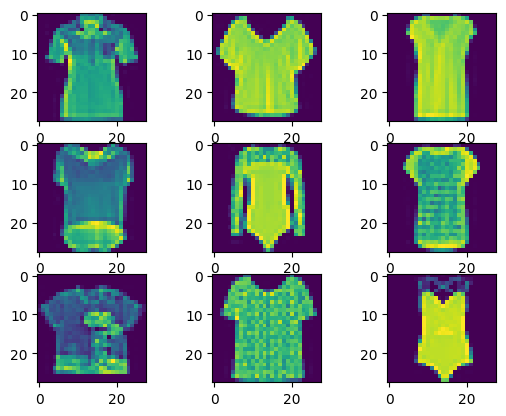

In [22]:
idx = np.flatnonzero((y_true==0) & (y_pred==6))
fig, ax = plt.subplots(nrows=3, ncols=3)
for i, a in enumerate(ax.ravel()):
    a.imshow(X_test[idx[i]].numpy().transpose(1,2,0))

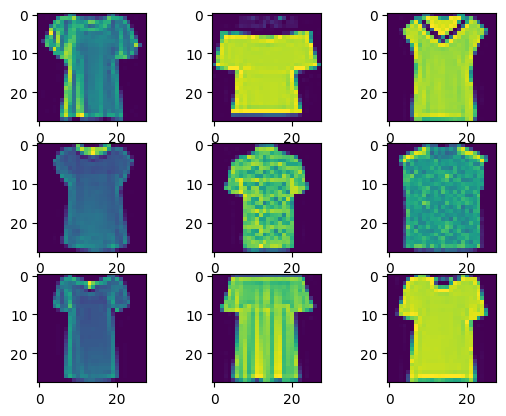

In [24]:
idx = np.flatnonzero((y_true==6) & (y_pred==0))
fig, ax = plt.subplots(nrows=3, ncols=3)
for i, a in enumerate(ax.ravel()):
    a.imshow(X_test[idx[i]].numpy().transpose(1,2,0))

In [34]:
mg = nn.Sequential(nn.Conv2d(1, 16, 3, padding="same"), nn.ReLU(),
                   nn.Conv2d(16, 16, 3, padding="same"), nn.ReLU(),
                   nn.Flatten(),
                   nn.Linear(16*28*28, 64), nn.ReLU(),
                   nn.Linear(64, 10),
)
fit(mg)

  0%|          | 0/5 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8718 0.3621651638031006
Accuracy/loss at epoch 1 : 0.8822 0.3264363388299942
Accuracy/loss at epoch 2 : 0.8869 0.30496464788913724
Accuracy/loss at epoch 3 : 0.8962 0.28475388689041137
Accuracy/loss at epoch 4 : 0.8996 0.28504941267967226


{'loss': [0.3212800014813741,
  0.2766181779225667,
  0.24338836959203083,
  0.20700385247866313,
  0.18749192547798157],
 'val_loss': [0.3621651638031006,
  0.3264363388299942,
  0.30496464788913724,
  0.28475388689041137,
  0.28504941267967226],
 'accuracy': [0.8850666666666667,
  0.8982333333333333,
  0.9107166666666666,
  0.9247,
  0.9307333333333333],
 'val_accuracy': [0.8718, 0.8822, 0.8869, 0.8962, 0.8996]}

In [27]:
class BackwardHook:
    """Catch output gradient of a layer."""
    def __init__(self, verbose=0):
        self.verbose = verbose
        self.grad = None
    def __call__(self, module, grad_input, grad_output):
        if self.verbose > 0:
            print("Enter backward hook")
        # grad_output is a tuple
        self.grad = grad_output[0].detach().clone()
        if self.verbose > 0:
            print("Grad shape", self.grad.shape)

In [28]:
class ForwardHook:
    """Catch output of a layer."""
    def __init__(self, verbose=0):
        self.verbose = verbose
        self.output = None
    def __call__(self, module, args, output):
        if self.verbose > 0:
            print("Enter forward hook")
        self.output = output.detach().clone()
        if self.verbose > 0:
            print("Output shape", self.output.shape)

In [35]:
layers = list(mg.children())
conv_output = layers[3]  # output of last convolutional layer
print(conv_output)
fh = ForwardHook(verbose=0)
fh_handle = conv_output.register_forward_hook(fh)
bh = BackwardHook(verbose=0)
bh_handle = conv_output.register_full_backward_hook(bh)

ReLU()


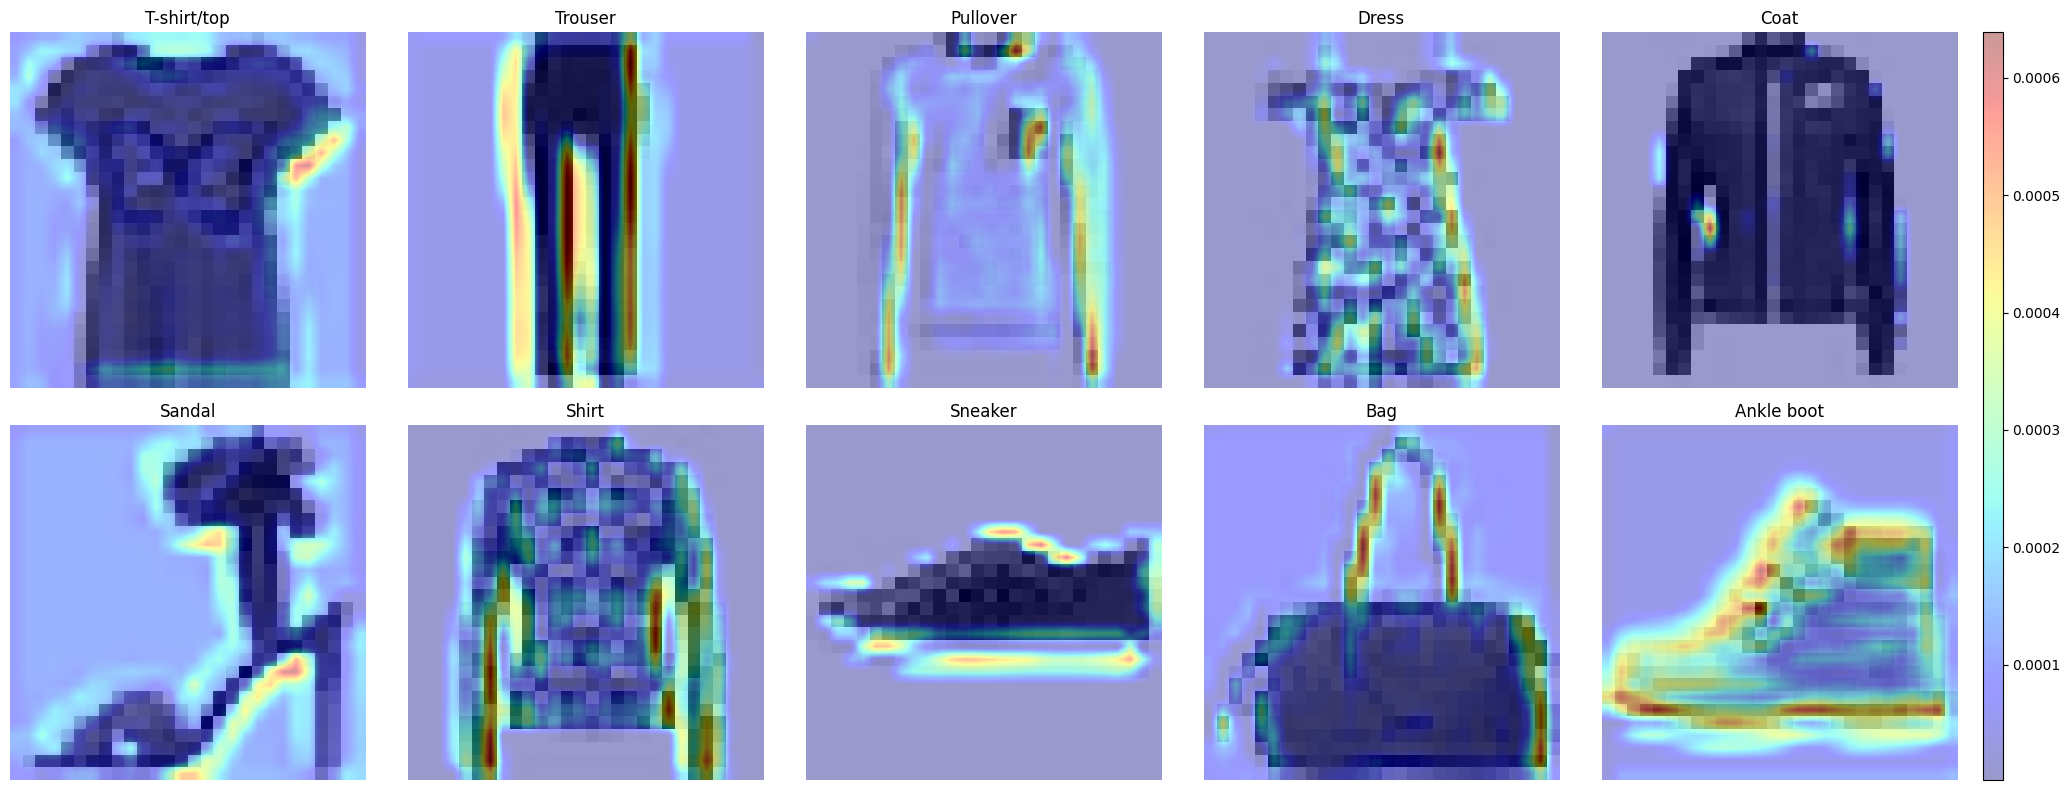

In [59]:
import matplotlib.gridspec as gridspec
import random

class_indices = {}
for cls in range(10):
    indices = (y_test == cls).nonzero(as_tuple=True)[0].tolist()
    if indices:
        class_indices[cls] = random.choice(indices)

fig = plt.figure(figsize=(22, 8))  # Wider figure for more colorbar space
gs = gridspec.GridSpec(2, 6, width_ratios=[1, 1, 1, 1, 1, 0.05])  # Last column for colorbar

axes = [fig.add_subplot(gs[i // 5, i % 5]) for i in range(10)]  # First 5 columns for images

for idx, (cls, i) in enumerate(class_indices.items()):
    # compute the gradient and conv outputs
    y = mg(X_test[i:i+1].to(device))
    yi = y.argmax().item()
    y[0, yi].backward()

    # weights for conv filters
    alpha = bh.grad.mean(axis=(2, 3))  # average over pixels
    A = fh.output  # activations

    alpha_r = alpha.reshape(alpha.shape[0], alpha.shape[1], 1, 1)
    heatmap = F.relu((A * alpha_r).mean(axis=1))

    # plot heatmap in subplot
    ax = axes[idx]
    im = ax.imshow(X_test[i].numpy().transpose(1, 2, 0), cmap="Greys")
    im2 = ax.imshow(heatmap[0, :, :].cpu(), interpolation="bilinear", alpha=0.4, cmap="jet")
    ax.set_title(labels[cls])
    ax.axis('off')

# Add a colorbar in the 6th column
cax = fig.add_subplot(gs[:, -1])  # Colorbar axis
fig.colorbar(im2, cax=cax)

plt.tight_layout()
plt.subplots_adjust(right=0.92)  # Ensure space for colorbar
plt.show()